In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Частный случай $X \in \mathbb{R}^2$

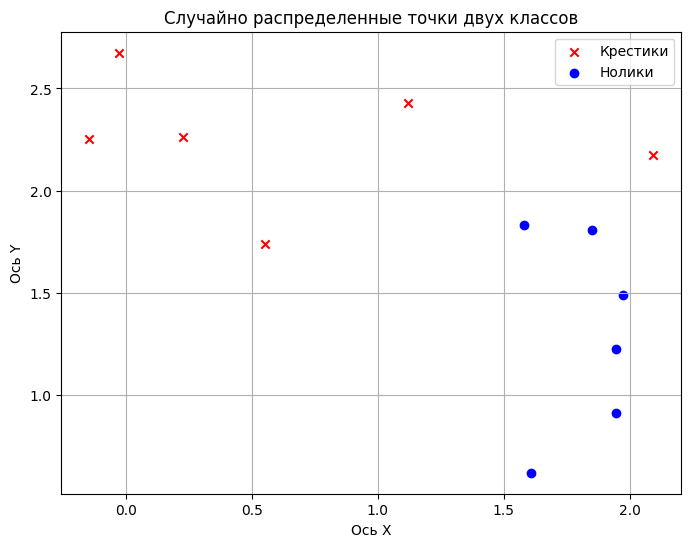

[ 0.55125338 -0.14608125 -0.0292297   2.09372943  1.1187106   0.22721727]


In [748]:
# Generate data for 'crosses'
# np.random.seed(0) # for reproducibility
num_points = 6

# случайное расположение
# cross_x = np.random.rand(num_points) * 10 
# cross_y = np.random.rand(num_points) * 10 
# zero_x = np.random.rand(num_points) * 10
# zero_y = np.random.rand(num_points) * 10

# кластеры
cross_x = np.random.normal(1, 0.5, num_points)
cross_y = np.random.normal(2, 0.5, num_points)
zero_x = np.random.normal(2, 0.5, num_points)
zero_y = np.random.normal(1, 0.5, num_points)

# Create plot
plt.figure(figsize=(8, 6))
plt.scatter(cross_x, cross_y, marker='x', color='red', label='Крестики')
plt.scatter(zero_x, zero_y, marker='o', color='blue', label='Нолики')

plt.xlabel('Ось X')
plt.ylabel('Ось Y')
plt.title('Случайно распределенные точки двух классов')
plt.legend()
plt.grid(True)
plt.show()

print(cross_x)

In [749]:
# cross_x = [1, 2, 4, 6, 9, 9]
# cross_y = [3, 5, 8, 2, 1, 5]

# zero_x = [2, 3, 4, 7, 8]
# zero_y = [7, 3, 5, 6, 3]

In [750]:
# X = np.concatenate((cross_x, zero_x), axis=0)
# Y = np.concatenate((cross_y, zero_y), axis=0)
XY = [((x, y), 1) for x,y in zip(cross_x, cross_y)] + [((x, y), 0) for x,y in zip(zero_x, zero_y)]
np.random.shuffle(XY)
# XY

In [751]:
def show_area_X(a, b1, b2):
    x = np.linspace(0, 10, 400)
    y = np.linspace(0, 10, 400)
    X, Y = np.meshgrid(x, y)

    # Построение графика
    plt.figure(figsize=(6, 6))
    
    # Настройка осей
    plt.axvline(x=a, color='black', linewidth=2, linestyle='--', label='x = a')
    plt.axhline(y=b1, color='black', linewidth=2, linestyle='--', label='y = b1')
    plt.axhline(y=b2, color='black', linewidth=2, linestyle='--', label='y = b2')
    
    # Подписи и легенда
    plt.xlabel('x')
    plt.ylabel('y')
    plt.scatter(cross_x, cross_y, marker='x', color='red', label='Крестики')
    plt.scatter(zero_x, zero_y, marker='o', color='blue', label='Нолики')
    plt.legend()

    plt.grid(True)
    plt.show()

def show_area_Y(a, b1, b2):
    x = np.linspace(0, 10, 400)
    y = np.linspace(0, 10, 400)
    X, Y = np.meshgrid(x, y)

    # Построение графика
    plt.figure(figsize=(6, 6))
    
    # Настройка осей
    plt.axhline(y=a, color='black', linewidth=2, linestyle='--', label='y = a')
    plt.axvline(x=b1, color='black', linewidth=2, linestyle='--', label='x = b1')
    plt.axvline(x=b2, color='black', linewidth=2, linestyle='--', label='x = b2')
    
    # Подписи и легенда
    plt.xlabel('x')
    plt.ylabel('y')
    plt.scatter(cross_x, cross_y, marker='x', color='red', label='Крестики')
    plt.scatter(zero_x, zero_y, marker='o', color='blue', label='Нолики')
    plt.legend()

    plt.grid(True)
    plt.show()


In [752]:
# 1 - крестик
# 0 - нолик
# def predict(a, b1, b2, x, y):
#     if x > a:
#         if y > b1:
#             return 1
#         else:
#             return 0

#     else:
#         if y > b2:
#             return 1
#         else:
#             return 0

def predict(a, b1, b2, x, y):
    if y > a:
        if x > b1:
            return 1
        else:
            return 0
    else:
        if x > b2:
            return 1
        else:
            return 0

def accuracy(a, b1, b2, XY):
    TP = TN = FP = FN = 0

    for xy, y in XY:
        p = predict(a, b1, b2, *xy)
        # print(p, y)

        if p == 1:
            if y == 1:
                TP += 1
            else:
                FP += 1
        else:
            if y == 0:
                TN += 1
            else:
                FN += 1

    return (TP + TN)/(TP+TN+FP+FN)

In [753]:
FEATURES = 3
SHIFT = 0.5
D = 2

def init(n, alpha=1):
    return [(np.random.rand(FEATURES)-SHIFT)*D*alpha for i in range(n)]

def mutation(generation, beta=1):
    n = len(generation[0])
    for gen in generation:
        gen += np.random.normal(size=n, loc=0, scale=beta)

def select_parents2(generation, p):
    evals = [(i, accuracy(*gen, XY)) for i, gen in enumerate(generation)]
    evals = sorted(evals, key=lambda el: 1-el[1])

    parents = [generation[i] for i, _ in evals]
    return parents
    
# турнирный отбор
def select_parents(generation, t):
    parents = []

    j = [i for i in range(len(generation))]
    
    for i in range(len(generation)):
        participants = [generation[k] for k in np.random.choice(j, size=t, replace=False)]

        m = 0
        qur = accuracy(*participants[0], XY)
        for k in range(1, len(participants)):
            temp = accuracy(*participants[k], XY)
            if temp > qur:
                qur = temp
                m = k
        # print(m)
        parents.append(participants[m])

    return parents

def crossover(gen1, gen2, gamma):
    new_gen = []
    for alley1, alley2 in zip(gen1, gen2):
        
        if alley2 < alley1:
            alley1, alley2 = alley2, alley1

        d1 = alley1 - gamma*(alley2 - alley1)
        d2 = alley2 + gamma*(alley2 - alley1)

        new_gen.append(d1 + np.random.rand()*(d2-d1))

    # print(f'{gen1=}\n {gen2=}\n {new_gen=}\n')

    return new_gen

def evalution(n, alpha = 1, beta = 1, t=4, gamma=0.5, teta=0, epoch=100):
    generation = init(n, alpha)
    # print(f'0: {generation}')

    for i in range(epoch):
        
        print(f'{i}: {len(generation)} ~ {max([accuracy(*gen, XY) for gen in generation])}')
        
        
        # выбор родителей 
        parents = select_parents(generation, t)
        # parents = select_parents2(generation, n//2)
        
        # print(generation, parents, sep='\n\n')
        # print([(accuracy(*x, XY), accuracy(*y, XY)) for x,y in zip(generation, parents)])

        # скрещивание смещением
        j = [i for i in range(len(parents))]
        multiplied = set()
        new_gen = []
        for i in range(len(parents)):
            a, b = np.random.choice(j, size=2, replace=False)
            multiplied.add(a)
            multiplied.add(b)

            new_gen.append(crossover(parents[a], parents[b], gamma))

        if len(multiplied) != len(parents):
            for k in range(len(parents)):
                if k not in multiplied:
                    new_gen.append(parents[k])
        
        # print(len(multiplied))
        # print(len(new_gen))
        # print([accuracy(*el, XY) for el in generation])
        # print([accuracy(*el, XY) for el in new_gen])

        # мутация
        mutation(new_gen, beta)

        # new_gen += parents[:2]

        # удаление нежизнеспособных особей
        generation = []

        for gen in new_gen:
            if accuracy(*gen, XY) > teta:
                generation.append(gen)

        # break
    return generation

In [754]:
n = 1000     # число особей в первом поколении
t = 8        # число особей учавствующих в турнире
alpha = 10   # зменчивость первого поколения
beta  = 0.5  # изменчивость мутаций
gamma = 0.5  # изменчивость при скрещивании
teta = 0.55  # граница жизнеспособности
epoch = 20   # количество поколений


generation = evalution(n, alpha=alpha, beta=beta, t=t, gamma=gamma, teta=teta, epoch=epoch)
# generation = evalution(n, coordinate_order, XY, alpha=alpha, beta=beta, t=t, gamma=gamma, teta=teta, epoch=epoch)

0: 1000 ~ 0.9166666666666666
1: 76 ~ 0.9166666666666666
2: 87 ~ 0.9166666666666666
3: 98 ~ 0.9166666666666666
4: 109 ~ 0.9166666666666666
5: 121 ~ 0.9166666666666666
6: 142 ~ 0.9166666666666666
7: 163 ~ 0.9166666666666666
8: 174 ~ 0.9166666666666666
9: 193 ~ 0.9166666666666666
10: 218 ~ 0.9166666666666666
11: 236 ~ 0.9166666666666666
12: 265 ~ 0.9166666666666666
13: 291 ~ 0.9166666666666666
14: 321 ~ 0.9166666666666666
15: 358 ~ 0.9166666666666666
16: 393 ~ 0.9166666666666666
17: 451 ~ 0.9166666666666666
18: 504 ~ 0.9166666666666666
19: 562 ~ 0.9166666666666666


In [755]:
# gen = [np.float64(2.0029989282941445), np.float64(-9.721855551428845), np.float64(6.844468604334368)]
# XY2 = []
# for (x, y), p in XY:
#     if p == 0:
#         XY2.append(((x, y), 'M'))
#     else:
#         XY2.append(((x, y), 'B'))
# accuracy(gen, XY2, [0, 1])
# accuracy(*gen, XY)

In [756]:
# for gen in generation:
    # print(f'{gen=} | {accuracy(*gen, XY)}')
acc = [accuracy(*gen, XY) for gen in generation]
# print(max(acc))

best_gen = generation[acc.index(max(acc))]
print(best_gen)
print(accuracy(*best_gen, XY))

[np.float64(2.05562344699789), np.float64(-4.018608410974778), np.float64(6.779929743143991)]
0.9166666666666666


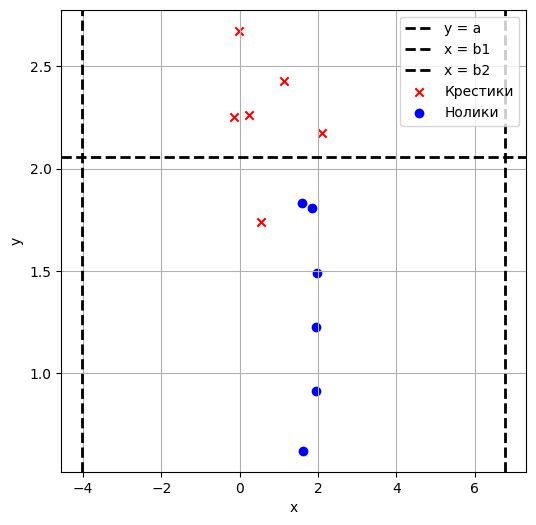

In [757]:
show_area_Y(*best_gen)

In [544]:
# for xy, y in XY:
#     print(f'({xy[0]:3.2f}, {xy[1]:3.2f}) | {y} : {predict(*best_gen, *xy)}')

# 2. Рак

In [576]:
from collections import defaultdict

In [727]:
# импорт данных
try:
  df = pd.read_csv('Cancer_Data.csv')
  display(df.head())
except FileNotFoundError:
  print("Error: 'Cancer_Data.csv' not found. Please replace it with the correct file path or name.")


X = df.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1)
Y = df['diagnosis']

# print("\nСредние значения:")
# print(X.mean(numeric_only=True))

means = X.mean(numeric_only=True)
for i, (col, mean_val) in enumerate(means.items()):
    print(f"{i:2d}: {col:30} {mean_val:20.6f}")

X = X.to_numpy()
Y = Y.to_numpy()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


 0: radius_mean                               14.127292
 1: texture_mean                              19.289649
 2: perimeter_mean                            91.969033
 3: area_mean                                654.889104
 4: smoothness_mean                            0.096360
 5: compactness_mean                           0.104341
 6: concavity_mean                             0.088799
 7: concave points_mean                        0.048919
 8: symmetry_mean                              0.181162
 9: fractal_dimension_mean                     0.062798
10: radius_se                                  0.405172
11: texture_se                                 1.216853
12: perimeter_se                               2.866059
13: area_se                                   40.337079
14: smoothness_se                              0.007041
15: compactness_se                             0.025478
16: concavity_se                               0.031894
17: concave points_se                          0

In [728]:
percantage = 0.1                  # процент данных в test
selected_columns = [3, 7, 8, 9]   # выбранные столбцы


test_n = int(percantage*len(XY))
j = [i for i in range(len(XY))]
test = np.random.choice(j, size=test_n, replace=False)
j = np.isin(j, test)


sc = np.isin([i for i in range(len(X[0]))], selected_columns)
X = X[:, selected_columns]

XY = [(x, y) for x, y in zip(X, Y)]

testX = []
testY = []
trainX = []
trainY = []
for f, (x, y) in zip(j, XY):
    if f:
        testX.append(x)
        testY.append(y)
    else:
        trainX.append(x)
        trainY.append(y)

In [729]:
# def predict(gen, x, coordinate_order):
#     n = len(x)
#     k = 0

#     # print(f'0: 0')

#     if n == 1:
#         if x[coordinate_order[-1]] < gen[k]:
#             return 'M'
#         else:
#             return 'B'

#     if x[coordinate_order[0]] < gen[0]:
#         k = 1
#     else:
#         k = 2

#     # print(f'1: {k}')

#     for i in range(1, n-1):
#         p = 2*k - i + 2**i - (i+1)%2

#         if x[coordinate_order[i]] < gen[k]:
#             k = p
#         else:
#             k = p+1

#         # print(f'{i+1}: {k}')
        
    
    
#     if x[coordinate_order[-1]] < gen[k]:
#         return 'M'
#     else:
#         return 'B'

def predict(gen, x, coordinate_order):
    n = len(x)
    
    if n == 1:
        return 'M' if x[coordinate_order[-1]] < gen[0] else 'B'
    
    node_index = 0
    
    for i in range(n):
        if x[coordinate_order[i]] < gen[node_index]:
            # Переход к левому потомку
            node_index = 2 * node_index + 1
        else:
            # Переход к правому потомку
            node_index = 2 * node_index + 2
        
        # Если достигли листа
        if node_index >= len(gen):
            break
    
    return 'M' if node_index % 2 == 1 else 'B'

def predict_batch(gen, X, coordinate_order):
    """Векторизованный predict"""
    n_features = len(coordinate_order)
    predictions = []
    
    for x in X:
        node_index = 0
        for i in range(n_features):
            if node_index >= len(gen):
                break
            if x[coordinate_order[i]] < gen[node_index]:
                node_index = 2 * node_index + 1
            else:
                node_index = 2 * node_index + 2
        predictions.append('M' if node_index % 2 == 1 else 'B')
    
    return predictions

def accuracy(gen, XY, coordinate_order):
    TP = TN = FP = FN = 0

    for x, y in XY:
        p = predict(gen, x, coordinate_order)
        # print(p, y)

        if p == 'B':
            if y == 'B':
                TP += 1
            else:
                FP += 1
        else:
            if y == 'M':
                TN += 1
            else:
                FN += 1

    return (TP + TN)/(TP+TN+FP+FN)

def accuracy_fast(gen, X, y_true, coordinate_order):
    """Быстрая accuracy с батч-предсказаниями"""
    predictions = predict_batch(gen, X, coordinate_order)
    
    TP = TN = FP = FN = 0
    for pred, true in zip(predictions, y_true):
        if pred == 'B' and true == 'B':
            TP += 1
        elif pred == 'B' and true == 'M':
            FP += 1
        elif pred == 'M' and true == 'M':
            TN += 1
        else:  # pred == 'M' and true == 'B'
            FN += 1
    
    return (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

In [730]:
FEATURES = 2**(len(XY[0][0])) - 1
SHIFT = 0.5
D = 2

def init(n, alpha=1):
    return [np.random.rand(FEATURES)*alpha for i in range(n)]

def mutation(generation, beta=1):
    for gen in generation:
        # gen += np.random.normal(size=FEATURES, loc=0, scale=beta)
        for i, alea in enumerate(gen):
            gen[i] = np.random.normal(loc=alea, scale=beta)

# турнирный отбор
def select_parents(generation, t, x, coordinate_order):
    parents = []

    j = [i for i in range(len(generation))]
    
    for i in range(len(generation)):
        participants = [generation[k] for k in np.random.choice(j, size=t, replace=False)]

        m = 0
        qur = accuracy(participants[0], x, coordinate_order)
        for k in range(1, len(participants)):
            temp = accuracy(participants[k], x, coordinate_order)
            if temp > qur:
                qur = temp
                m = k
        # print(m)
        parents.append(participants[m])

    return parents

def select_parents_fast(generation, t, X, y_true, coordinate_order):
    """Оптимизированный отбор с предварительным вычислением точности"""
    # Вычисляем точность один раз для всех особей
    fitness_scores = [accuracy_fast(gen, X, y_true, coordinate_order) for gen in generation]
    
    parents = []
    indices = list(range(len(generation)))
    
    for i in range(len(generation)):
        # Выбираем участников турнира
        participant_indices = np.random.choice(indices, size=t, replace=False)
        
        # Находим лучшего по предварительно вычисленным scores
        best_idx = participant_indices[0]
        best_score = fitness_scores[best_idx]
        
        for idx in participant_indices[1:]:
            if fitness_scores[idx] > best_score:
                best_score = fitness_scores[idx]
                best_idx = idx
        
        parents.append(generation[best_idx])
    
    return parents

def crossover(gen1, gen2, gamma):
    new_gen = []
    for alley1, alley2 in zip(gen1, gen2):
        
        if alley2 < alley1:
            alley1, alley2 = alley2, alley1

        d1 = alley1 - gamma*(alley2 - alley1)
        d2 = alley2 + gamma*(alley2 - alley1)
        
        d1 = d1 if d1>0 else 0
        
        new_gen.append(d1 + np.random.rand()*(d2-d1))

    # print(f'{gen1=}\n {gen2=}\n {new_gen=}\n')

    return new_gen

def evalution(n, coordinate_order, train, alpha = 1, beta = 1, t=4, gamma=0.5, teta=0, epoch=100):
    generation = init(n, alpha)
    # print(f'0: {generation}')

    for i in range(epoch):

        if i%10 == 0:
            print(f'{i}: {len(generation)} ~ {max([accuracy(gen, train, coordinate_order) for gen in generation])}')
        
        
        # выбор родителей 
        parents = select_parents(generation, t, train, coordinate_order)

        # скрещивание смещением
        j = [i for i in range(len(parents))]
        multiplied = set()
        new_gen = []
        for i in range(len(parents)):
            a, b = np.random.choice(j, size=2, replace=False)
            multiplied.add(a)
            multiplied.add(b)

            new_gen.append(crossover(parents[a], parents[b], gamma))

        if len(multiplied) != len(parents):
            for k in range(len(parents)):
                if k not in multiplied:
                    new_gen.append(parents[k])

        # мутация
        mutation(new_gen, beta)

        # удаление нежизнеспособных особей
        generation = []

        for gen in new_gen:
            if accuracy(gen, train, coordinate_order) > teta:
                generation.append(gen)

        # break
    return generation

def evolution_optimized(n, coordinate_order, X, y_true, alpha=1, beta=0.1, t=4, gamma=0.5, teta=0.6, epoch=100):
    """Оптимизированная версия эволюционного алгоритма"""
    generation = init(n, alpha)
    
    for i in range(epoch):
        # Предварительно вычисляем точность для всего поколения
        fitness_scores = [accuracy_fast(gen, X, y_true, coordinate_order) for gen in generation]
        best_score = max(fitness_scores)
        
        if i % 10 == 0:
            print(f'{i:5}: {len(generation):5}  ~ {best_score:6.3f}')
        
        # Отбор родителей (используем предварительно вычисленные scores)
        parents = select_parents_fast(generation, t, X, y_true, coordinate_order)
        
        # Скрещивание
        new_gen = []
        parent_indices = list(range(len(parents)))
        
        for _ in range(len(parents)):
            a, b = np.random.choice(parent_indices, size=2, replace=False)
            new_gen.append(crossover(parents[a], parents[b], gamma))
        
        # Мутация
        mutation(new_gen, beta)

        
        elete = []
        # Добавляем элиту
        if len(new_gen) < n:
            # Берем лучших из предыдущего поколения
            elite_indices = np.argsort(fitness_scores)[-min(5, n - len(generation)):]
            elete.extend([generation[idx] for idx in elite_indices])
        
        # Отбор с порогом (используем предварительно вычисленные scores для родителей)
        generation = []
        for gen in new_gen:
            # Вычисляем точность только один раз для новой особи
            acc = accuracy_fast(gen, X, y_true, coordinate_order)
            if acc > teta:
                generation.append(gen)

        generation.extend(elete)
        
    
    return generation

In [743]:
n = 300                         # число особей в первом поколении
t = 16                          # число особей учавствующих в турнире
alpha = 10                     # зменчивость первого поколения
beta  = 0.2                    # изменчивость мутаций
gamma = 0.5                     # изменчивость при скрещивании
teta = 0.3                      # граница жизнеспособности
epoch = 200                     # количество поколений
coordinate_order = [0, 1, 2, 3] # порядок следования координат при предсказании

generation = evolution_optimized(n, coordinate_order, trainX, trainY, alpha=alpha, beta=beta, t=t, gamma=gamma, teta=teta, epoch=epoch)

    0:   300 ~  0.641
   10:   300 ~  0.903
   20:   300 ~  0.908
   30:   300 ~  0.906
   40:   300 ~  0.908
   50:   300 ~  0.908
   60:   300 ~  0.906
   70:   300 ~  0.908
   80:   300 ~  0.901
   90:   300 ~  0.906
  100:   300 ~  0.903
  110:   300 ~  0.908
  120:   300 ~  0.906
  130:   300 ~  0.908
  140:   300 ~  0.899
  150:   300 ~  0.908
  160:   300 ~  0.908
  170:   300 ~  0.908
  180:   300 ~  0.897
  190:   300 ~  0.904


In [747]:
# generation

In [745]:
acc = [accuracy_fast(gen, testX, testY, coordinate_order) for gen in generation]
# print(max(acc))

best_gen = generation[acc.index(max(acc))]
# print(best_gen)
# print(accuracy(best_gen, test, coordinate_order))
s = ''
for alea in best_gen:
    s += f'{alea:.4f}, '
s = s[:-2]
print(s)
print(f'\naccuracy={accuracy_fast(best_gen, testX, testY, coordinate_order):.2f}')
print(f'{n}, {t}, {alpha}, {beta}, {gamma}, {teta}, {epoch}')
print(f'{selected_columns=}')
print(f'{coordinate_order=}')

125.5879, 1390.5117, 0.0579, 13.6113, 89.8214, 43.9489, 10.9167, 19.5124, 4950.4718, 10.8855, 32.2466, -0.1740, 399.5074, 127.6673, 54.2367

accuracy=0.96
300, 16, 10, 0.2, 0.5, 0.3, 200
selected_columns=[3, 7, 8, 9]
coordinate_order=[0, 1, 2, 3]


In [746]:
dataframe = pd.DataFrame([
        [0.89, [0, 1, 2, 3], [0, 1, 2, 3], 500, 16, 10, 0.8, 0.5, 0.3, 200],
        [0.91, [0, 1, 2, 3], [1, 0, 2, 3], 500, 16, 10, 0.8, 0.5, 0.3, 200],
        [0.89, [0, 4, 5, 6], [0, 1, 2, 3], 500, 16, 10, 0.8, 0.5, 0.3, 200],
        [0.86, [1, 2, 5, 6], [1, 0, 2, 3], 500, 16, 10, 0.8, 0.5, 0.3, 200],
        [0.96, [3, 7, 8, 9], [0, 1, 2, 3], 300, 16, 10, 0.2, 0.5, 0.3, 200]
    ], 
    columns=["Accuracy", "Selected columns", "Coordinate order", "n", "t", "alpha", "beta", "gamma", "teta", "epoch"])
dataframe

,Accuracy,Selected columns,Coordinate order,n,t,alpha,beta,gamma,teta,epoch
0,0.89,"[0, 1, 2, 3]","[0, 1, 2, 3]",500,16,10,0.8,0.5,0.3,200
1,0.91,"[0, 1, 2, 3]","[1, 0, 2, 3]",500,16,10,0.8,0.5,0.3,200
2,0.89,"[0, 4, 5, 6]","[0, 1, 2, 3]",500,16,10,0.8,0.5,0.3,200
3,0.86,"[1, 2, 5, 6]","[1, 0, 2, 3]",500,16,10,0.8,0.5,0.3,200
4,0.96,"[3, 7, 8, 9]","[0, 1, 2, 3]",300,16,10,0.2,0.5,0.3,200


In [ ]:
#0 [6715.3064, 17.5017, 40490.7240, 26.7607, 91.8373, 1420.0708, 346784.6454, 13960.4853, 90.2161, 56.8088, 4871.1958, 2731.1234, 1449.6859, 1900.6181, 2867.9733]
#1 [15711.6685, 15.3599, 21113.8656, 934.8114, 61315.4007, 7330.9092, 431664.9734, 89.5272, 1061.3937, 3360.8668, 8632.2399, 28259.6507, 1262.5994, 13288.7365, 347.7722]
#2 [14.8191, 55.6071, 103.7718, 371.7034, 15.4774, 69.1417, 6149.0674, -0.3023, 51.3756, 22.0071, 305.0155, 44.7077, 430.3002, 34.8256, 31.6038]
#3 [5.8777, 8.2366, 6.1755, 6.1244, 4.6612, 15.7874, 0.1173, 6.6406, 6.2967, 8.3304, 10.5739, -0.8837, 1.4748, -0.8908, 10.2795]
#4 [125.5879, 1390.5117, 0.0579, 13.6113, 89.8214, 43.9489, 10.9167, 19.5124, 4950.4718, 10.8855, 32.2466, -0.1740, 399.5074, 127.6673, 54.2367]
